# Analysis of ESG ETF Excess Returns During Periods of High Inflation in the United States (2021-2024)

**Author:** Samoilova Mariia Leonidovna | group БПАД241, 2nd year of study

**Supervisor:** Bashminova Daria Alexandrovna | Senior Lecturer, HSE University, Faculty of Computer Science



## Research Question
To what extent are ESG ETF excess returns influenced by inflation expectations, market volatility, and the high-inflation regime in the United States during 2021-2024?




## Notebook Overview
The analysis starts with the raw merged ESG ETF dataset and prepares it for empirical analysis. The notebook then presents descriptive statistics, visual analysis, regression results, hypothesis testing, and machine learning model comparison.

## Notebook Structure

The notebook is divided into seven main sections:

1. **Data Loading and Preprocessing**  
   The raw dataset is loaded, checked for missing values, cleaned, and prepared for further analysis.

2. **Descriptive Statistics**  
   The main variables are summarized using basic descriptive statistics.

3. **Correlation Analysis and Figures**  
   Correlations and visual figures are used to explore relationships between ESG ETF excess returns and macro-financial variables.

4. **Econometric Model**  
   A baseline OLS regression model is estimated to examine the relationship between excess returns and the selected explanatory variables.

5. **Hypothesis Testing**  
   The main research hypotheses are tested using regression results and a two-sample t-test.

6. **Machine Learning Models**  
   Linear Regression, Ridge Regression, and Random Forest models are used to compare predictive performance.

7. **Feature Importance**  
   Random Forest feature importance is used to identify the most relevant predictors in the machine learning model.

## 1. Data Loading and Preprocessing

In [7]:
import os
import pandas as pd

DATA_PATH = "esg_dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "The file esg_dataset.csv is not found. Place it in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)
df.head()

,date,ticker,adj_close,return,excess_return,volume,log_volume,t5yie,sofr,dgs10,vix,rf_daily,high_inflation
0,2021-01-04,ACES,76.321014,NaN,NaN,NaN,NaN,1.98,0.1,0.93,26.969999,0.000004,0
1,2021-01-04,CNRG,102.446007,NaN,NaN,NaN,NaN,1.98,0.1,0.93,26.969999,0.000004,0
2,2021-01-04,DRIV,22.535343,NaN,NaN,NaN,NaN,1.98,0.1,0.93,26.969999,0.000004,0
3,2021-01-04,DSI,66.633217,NaN,NaN,NaN,NaN,1.98,0.1,0.93,26.969999,0.000004,0
4,2021-01-04,EFAX,33.873035,NaN,NaN,NaN,NaN,1.98,0.1,0.93,26.969999,0.000004,0


In [51]:
print("Initial shape:", df.shape)
df.info()

Initial shape: (26104, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26104 entries, 0 to 26103
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            26104 non-null  object 
 1   ticker          26104 non-null  object 
 2   adj_close       26104 non-null  float64
 3   return          26078 non-null  float64
 4   excess_return   25896 non-null  float64
 5   volume          1004 non-null   float64
 6   log_volume      1004 non-null   float64
 7   t5yie           25922 non-null  float64
 8   sofr            25922 non-null  float64
 9   dgs10           25922 non-null  float64
 10  vix             26104 non-null  float64
 11  rf_daily        25922 non-null  float64
 12  high_inflation  26104 non-null  int64  
dtypes: float64(10), int64(1), object(2)
memory usage: 2.6+ MB


### Cleaning and preprocessing

The raw dataset is prepared for further analysis by converting dates, sorting the panel, checking missing values, removing columns with excessive missing data, and dropping incomplete observations.

In [52]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "ticker"]).reset_index(drop=True)

In [53]:
missing_share = df.isna().mean().sort_values(ascending=False)
missing_table = (missing_share * 100).round(2).to_frame("% of missing values")

display(missing_table)

,% of missing values
volume,96.15
log_volume,96.15
excess_return,0.80
sofr,0.70
t5yie,0.70
dgs10,0.70
rf_daily,0.70
return,0.10
date,0.00
ticker,0.00


Columns with more than 10% missing values are removed because they are not reliable for further analysis.

In [59]:
columns_to_drop = missing_share[missing_share > 0.10].index.tolist()

print("Columns removed:", columns_to_drop)

df = df.drop(columns=columns_to_drop, errors="ignore")

print("Shape after removing columns:", df.shape)

Columns removed: ['volume', 'log_volume']
Shape after removing columns: (26104, 11)


Checking for duplicate observations

In [60]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


Removing duplicate observations

In [61]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (26104, 11)


Checking remaining missing values

In [62]:
remaining_missing = (df.isna().mean() * 100).round(2)
remaining_missing

,0
date,0.0
ticker,0.0
adj_close,0.0
return,0.1
excess_return,0.8
t5yie,0.7
sofr,0.7
dgs10,0.7
vix,0.0
rf_daily,0.7


## 2. Descriptive Statistics

In [63]:
df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (25896, 11)


Number of unique ETF tickers after cleaning

In [64]:
print("Number of unique tickers:", df["ticker"].nunique())

Number of unique tickers: 26


Number of ETF observations per trading day

In [65]:
daily_observation_counts = df.groupby("date")["ticker"].count().value_counts().sort_index()
daily_observation_counts

,count
ticker,
26,996


Saving the cleaned dataset

In [8]:
CLEANED_OUTPUT_PATH = "esg_dataset_cleaned.csv"

df.to_csv(CLEANED_OUTPUT_PATH, index=False)

print("Saved cleaned dataset to:", CLEANED_OUTPUT_PATH)

Saved cleaned dataset to: esg_dataset_cleaned.csv


In [67]:
variables_for_summary = ["return", "excess_return", "t5yie", "sofr", "dgs10", "vix"]

summary_table = df[variables_for_summary].agg(
    ["count", "mean", "std", "min", "median", "max"]
).T

summary_table.columns = ["N", "Mean", "Std.Dev", "Min", "Median", "Max"]

summary_table.round(4)

,N,Mean,Std.Dev,Min,Median,Max
return,25896.0,0.0000,0.0161,-0.1086,0.0002,0.1282
excess_return,25896.0,-0.0001,0.0161,-0.1088,0.0000,0.1282
t5yie,25896.0,2.4571,0.3192,1.8600,2.3900,3.5900
sofr,25896.0,2.9583,2.3165,0.0100,4.3000,5.4000
dgs10,25896.0,3.1415,1.1723,0.9600,3.5700,4.9800
vix,25896.0,19.4240,5.2758,11.8600,18.5000,38.5700


In [68]:
print("Number of unique trading dates:", df["date"].nunique())

Number of unique trading dates: 996


## 3. Correlation Analysis and Figures

In [69]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import seaborn as sns

mpl.rcParams["figure.figsize"] = (8, 5)
mpl.rcParams["font.size"] = 11
mpl.rcParams["axes.labelsize"] = 11
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["legend.fontsize"] = 10
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3

main_color = "#8E7CC3"
light_color = "#D9D2E9"

start_date = pd.Timestamp("2021-01-01")
end_date = pd.Timestamp("2024-12-31")


def format_time_axis(ax):
    ax.set_xlim(start_date, end_date)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=0)

### 3.1 Correlation matrix

The correlation matrix shows the pairwise relationships between ESG ETF returns and selected macro-financial variables.

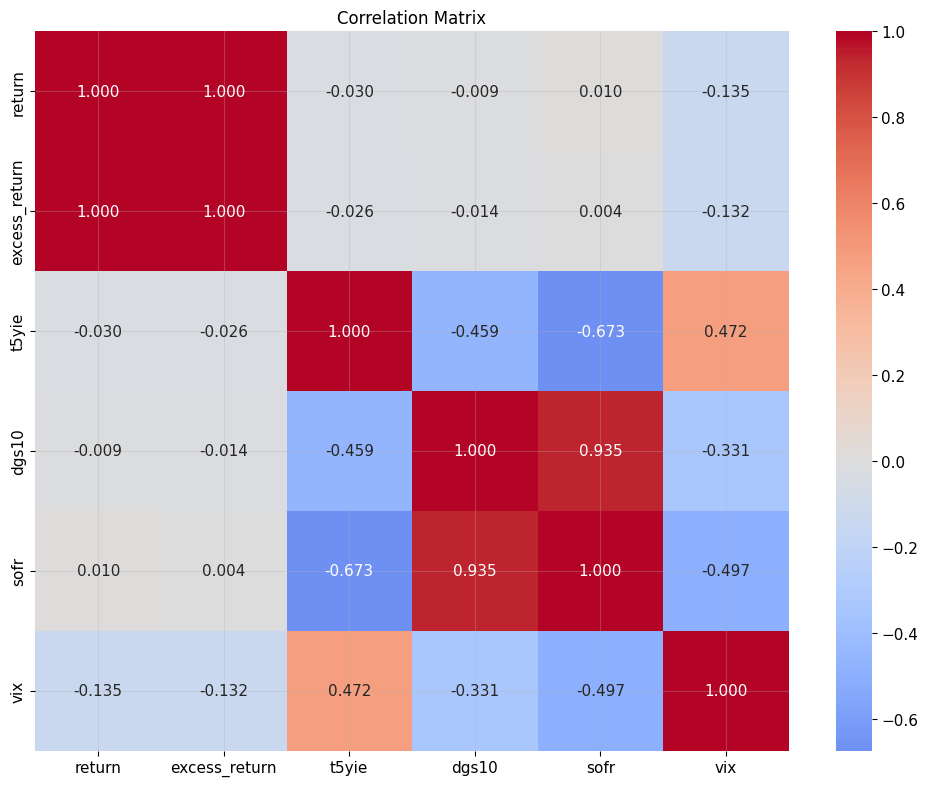

In [70]:
correlation_variables = [
    "return",
    "excess_return",
    "t5yie",
    "dgs10",
    "sofr",
    "vix",
]

correlation_matrix = df[correlation_variables].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".3f",
    ax=ax,
)

ax.set_title("Correlation Matrix")
fig.tight_layout()
fig.savefig("correlation_matrix.pdf", bbox_inches="tight")

plt.show()


### 3.2 Average ESG ETF excess return over time

This figure shows the average daily excess return across ESG ETFs during the sample period.

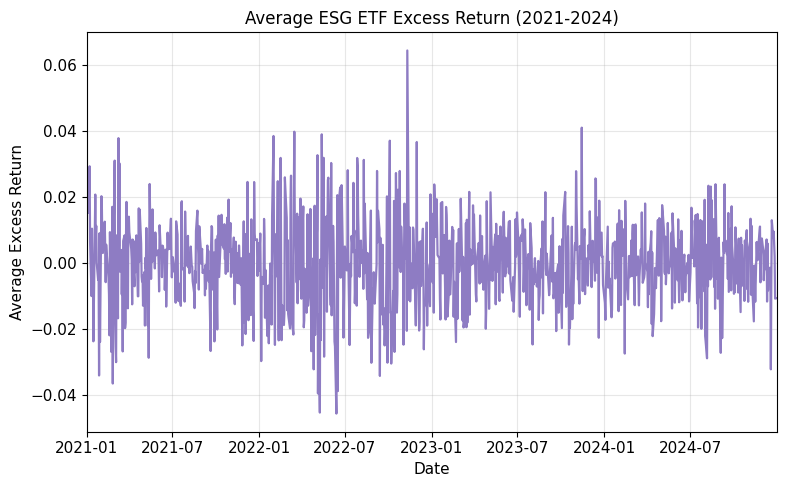

In [71]:
daily_mean_excess_return = df.groupby("date")["excess_return"].mean()

fig, ax = plt.subplots()

ax.plot(
    daily_mean_excess_return.index,
    daily_mean_excess_return.values,
    color=main_color,
    linewidth=1.6,
)

ax.set_title("Average ESG ETF Excess Return (2021-2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Average Excess Return")

format_time_axis(ax)

fig.tight_layout()
fig.savefig("figure_2.pdf", bbox_inches="tight")

plt.show()

### 3.3 Excess returns across inflation regimes

This figure compares the distribution of ESG ETF excess returns in low- and high-inflation regimes.

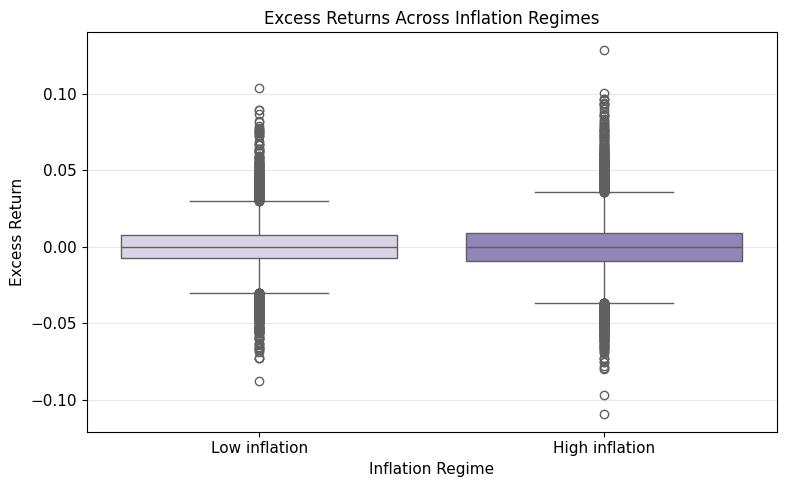

In [72]:
fig, ax = plt.subplots()

sns.boxplot(
    data=df,
    x="high_inflation",
    y="excess_return",
    hue="high_inflation",
    palette={0: light_color, 1: main_color},
    legend=False,
    ax=ax,
)

ax.set_title("Excess Returns Across Inflation Regimes")
ax.set_xlabel("Inflation Regime")
ax.set_ylabel("Excess Return")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Low inflation", "High inflation"])

fig.tight_layout()
fig.savefig("figure_3.pdf", bbox_inches="tight")

plt.show()

### 3.4 Average excess return with high-inflation regime shading

This figure shows the average ESG ETF excess return together with shaded high-inflation periods.

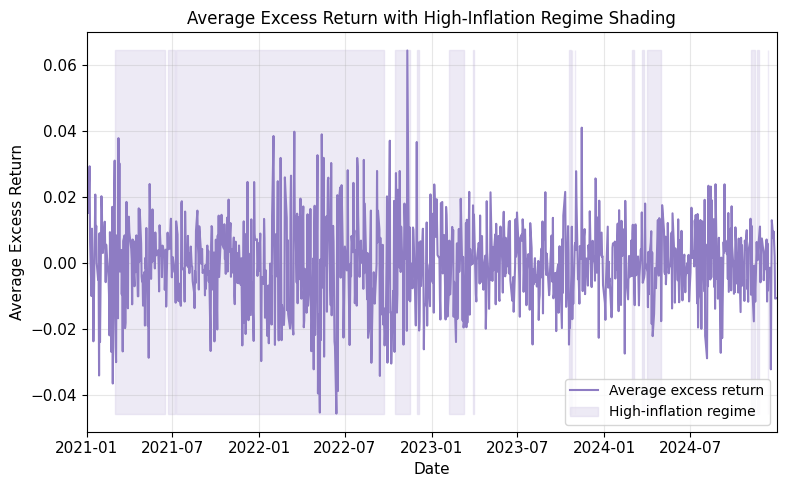

In [73]:
daily_data = (
    df.groupby("date")
    .agg(
        avg_excess_return=("excess_return", "mean"),
        high_inflation=("high_inflation", "max"),
    )
    .reset_index()
)

fig, ax = plt.subplots()

ax.plot(
    daily_data["date"],
    daily_data["avg_excess_return"],
    color=main_color,
    linewidth=1.5,
    label="Average excess return",
)

ax.fill_between(
    daily_data["date"],
    daily_data["avg_excess_return"].min(),
    daily_data["avg_excess_return"].max(),
    where=daily_data["high_inflation"] == 1,
    color=light_color,
    alpha=0.45,
    label="High-inflation regime",
)

ax.set_title("Average Excess Return with High-Inflation Regime Shading")
ax.set_xlabel("Date")
ax.set_ylabel("Average Excess Return")
ax.legend()

format_time_axis(ax)

fig.tight_layout()
fig.savefig("figure_4.pdf", bbox_inches="tight")

plt.show()

### 3.5 Excess returns and inflation expectations

This scatter plot shows the relationship between ESG ETF excess returns and inflation expectations measured by T5YIE.

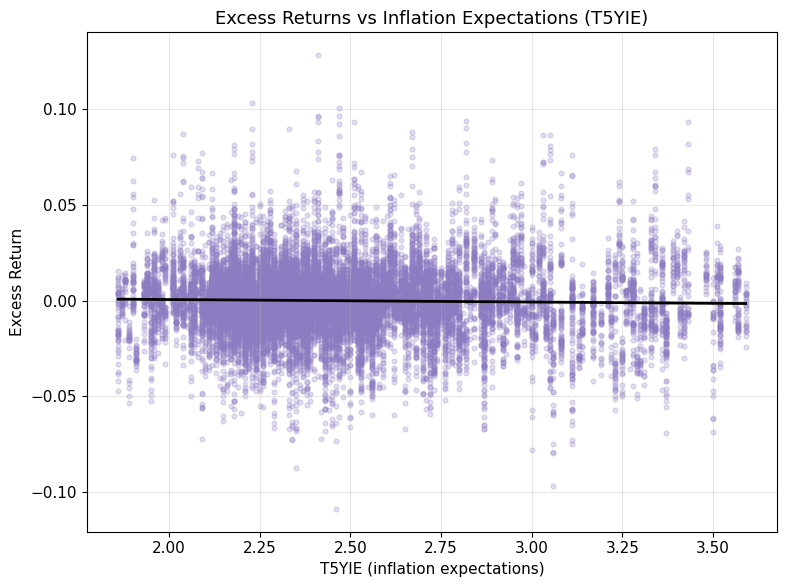

In [74]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=df,
    x="t5yie",
    y="excess_return",
    scatter_kws={
        "alpha": 0.25,
        "s": 12,
        "color": main_color,
    },
    line_kws={
        "linewidth": 2,
        "color": "black",
    },
    ax=ax,
)

ax.set_title("Excess Returns vs Inflation Expectations (T5YIE)", fontsize=13)
ax.set_xlabel("T5YIE (inflation expectations)")
ax.set_ylabel("Excess Return")

ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("figure_5.pdf", bbox_inches="tight")

plt.show()

### 3.6 Inflation expectations over time

This figure shows the dynamics of inflation expectations during 2021-2024.

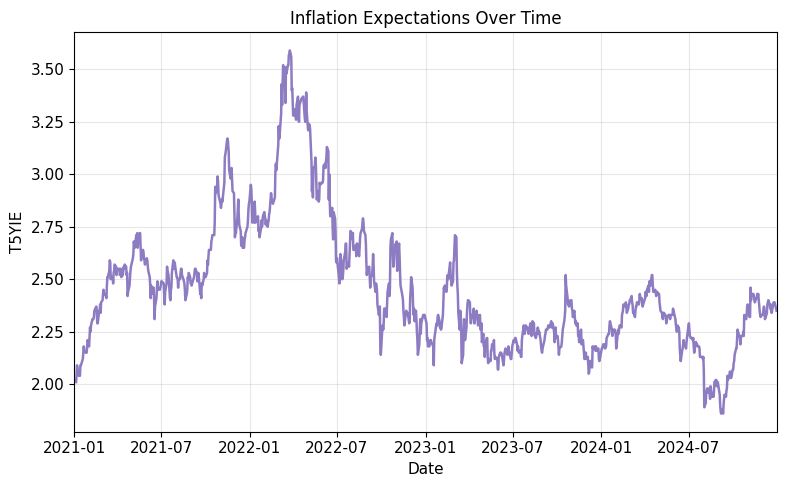

In [88]:
daily_t5yie = df.groupby("date")["t5yie"].mean()

fig, ax = plt.subplots()

ax.plot(
    daily_t5yie.index,
    daily_t5yie.values,
    color=main_color,
    linewidth=1.8,
)

ax.set_title("Inflation Expectations Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("T5YIE")

format_time_axis(ax)

fig.tight_layout()
fig.savefig("figure_6.pdf", bbox_inches="tight")

plt.show()

### 3.7 Market volatility over time

This figure shows the dynamics of market volatility during 2021-2024.

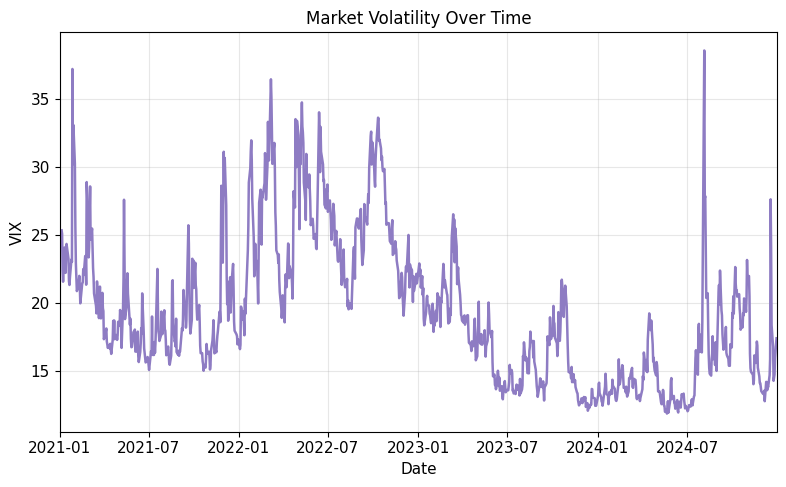

In [87]:
daily_vix = df.groupby("date")["vix"].mean()

fig, ax = plt.subplots()

ax.plot(
    daily_vix.index,
    daily_vix.values,
    color=main_color,
    linewidth=1.8,
)

ax.set_title("Market Volatility Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("VIX")

format_time_axis(ax)

fig.tight_layout()
fig.savefig("figure_7.pdf", bbox_inches="tight")

plt.show()

## 4. Econometric Model

This section estimates a baseline regression model to examine the relationship between ESG ETF excess returns and macro-financial variables.

### 4.1 Baseline OLS regression

The baseline regression model estimates ESG ETF excess returns as a function of inflation expectations, market volatility, interest rates, and the high-inflation regime dummy.

In [79]:
import statsmodels.formula.api as smf

regression_columns = [
    "excess_return",
    "t5yie",
    "vix",
    "dgs10",
    "sofr",
    "high_inflation",
]

regression_df = df.dropna(subset=regression_columns).copy()

ols_model = smf.ols(
    "excess_return ~ t5yie + vix + dgs10 + sofr + high_inflation",
    data=regression_df,
).fit(cov_type="HC1")

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     93.09
Date:                Mon, 01 Jun 2026   Prob (F-statistic):           1.74e-97
Time:                        14:55:45   Log-Likelihood:                 70516.
No. Observations:               25896   AIC:                        -1.410e+05
Df Residuals:                   25890   BIC:                        -1.410e+05
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0133      0.002      8.

### 4.2 Regression coefficients and p-values

The table below reports the coefficients and p-values for the main explanatory variables.

In [80]:
main_variables = ["t5yie", "vix", "dgs10", "sofr", "high_inflation"]

regression_results = pd.DataFrame({
    "Variable": main_variables,
    "Coefficient": [ols_model.params[var] for var in main_variables],
    "p_value": [ols_model.pvalues[var] for var in main_variables],
})

regression_results.round(4)

,Variable,Coefficient,p_value
0,t5yie,-0.0010,0.1512
1,vix,-0.0005,0.0000
2,dgs10,0.0009,0.0126
3,sofr,-0.0011,0.0000
4,high_inflation,0.0002,0.6159


## 5. Hypothesis Testing





### Regression-based hypothesis testing

In [81]:
alpha = 0.05

hypothesis_results = pd.DataFrame({
    "Hypothesis": [
        "H1: T5YIE has a negative effect on excess returns",
        "H2: VIX has a negative effect on excess returns",
        "H3: High-inflation regime affects excess returns",
    ],
    "Variable": [
        "t5yie",
        "vix",
        "high_inflation",
    ],
    "Coefficient": [
        ols_model.params["t5yie"],
        ols_model.params["vix"],
        ols_model.params["high_inflation"],
    ],
    "p_value": [
        ols_model.pvalues["t5yie"],
        ols_model.pvalues["vix"],
        ols_model.pvalues["high_inflation"],
    ],
})

hypothesis_results["Reject H0 at 5%"] = hypothesis_results["p_value"] < alpha

hypothesis_results.round(4)

,Hypothesis,Variable,Coefficient,p_value,Reject H0 at 5%
0,H1: T5YIE has a negative effect on excess returns,t5yie,-0.0010,0.1512,False
1,H2: VIX has a negative effect on excess returns,vix,-0.0005,0.0000,True
2,H3: High-inflation regime affects excess returns,high_inflation,0.0002,0.6159,False


### Two-sample t-test for inflation regimes

The two-sample t-test compares ESG ETF excess returns between low- and high-inflation regimes.

In [82]:
from scipy.stats import ttest_ind

low_inflation_returns = df.loc[
    df["high_inflation"] == 0,
    "excess_return",
]

high_inflation_returns = df.loc[
    df["high_inflation"] == 1,
    "excess_return",
]

t_statistic, p_value = ttest_ind(
    low_inflation_returns,
    high_inflation_returns,
    equal_var=False,
)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 1.0456605048417735
p-value: 0.29572804850851475


## 6. Machine Learning Models and Quality Metrics

This section compares several regression models for predicting ESG ETF excess returns using macro-financial variables.

In [83]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

features = [
    "t5yie",
    "vix",
    "dgs10",
    "sofr",
    "high_inflation",
]

target = "excess_return"

ml_df = df[features + [target]].dropna().copy()

X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (20716, 5)
Test size: (5180, 5)


The models are evaluated using a random 80/20 train-test split. This part is used as a simple predictive comparison rather than a strict time-series forecasting exercise.

In [84]:
linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
)

linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

pred_linear = linear_model.predict(X_test)
pred_ridge = ridge_model.predict(X_test)
pred_random_forest = random_forest_model.predict(X_test)

In [85]:
metrics_table = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Random Forest Regressor",
    ],
    "MAE": [
        mean_absolute_error(y_test, pred_linear),
        mean_absolute_error(y_test, pred_ridge),
        mean_absolute_error(y_test, pred_random_forest),
    ],
    "RMSE": [
        mean_squared_error(y_test, pred_linear) ** 0.5,
        mean_squared_error(y_test, pred_ridge) ** 0.5,
        mean_squared_error(y_test, pred_random_forest) ** 0.5,
    ],
    "R2": [
        r2_score(y_test, pred_linear),
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_random_forest),
    ],
})

metrics_table.round(6)

,Model,MAE,RMSE,R2
0,Linear Regression,0.011262,0.015937,0.019854
1,Ridge Regression,0.011262,0.015937,0.019854
2,Random Forest Regressor,0.010543,0.014839,0.150255


## 7. Feature Importance

This section reports feature importance values from the Random Forest model.

In [86]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest_model.feature_importances_,
}).sort_values("Importance", ascending=False)

feature_importance.round(6)

,Feature,Importance
1,vix,0.527714
2,dgs10,0.196110
0,t5yie,0.194544
3,sofr,0.072009
4,high_inflation,0.009623
